# 04 — Human Annotation Sample Creation

This notebook prepares a small, human-readable subset of transactions for manual category annotation.  
These labels are used later to evaluate model quality with real human judgments.

### What we do in this notebook

1. **Load the synthetic dataset (raw version)**  
   We use the *raw*, unprocessed version so annotators see the natural vendor text, description text, and purchase details.

2. **Drop model-generated or encoded category columns**  
   We remove fields like `category_encoded`, one-hot features, or anything containing the word `"category"` to prevent leakage.

3. **Remove fields irrelevant to human annotation**  
   Identifiers such as `user_id`, `entity_id`, `txn_id`, and internal indices are removed since they do not help annotators.

4. **Sample 50 transactions for annotation**  
   A small, diverse random sample (n=50) is selected from the full dataset for manual labeling.

5. **Add a blank column `human_category`**  
   This gives human annotators a place to enter their chosen category.

6. **Save the annotation CSV**  
   The file is saved to `data/annotation/annotation_sample.csv` for distribution to annotators or import into a labeling tool later.

In [1]:
import os
import pandas as pd

# ---------------------------------------------------------
# 1. Load the NEW synthetic transactions dataset (RAW version)
# ---------------------------------------------------------
# We intentionally load the *raw* dataset here because human
# annotators should see natural vendor names and descriptions
# before any cleaning, encoding, or feature engineering.
DATA_PATH = "../data/raw/transactions_synthetic.csv"
df = pd.read_csv(DATA_PATH)

print("Full dataset shape:", df.shape)

# ---------------------------------------------------------
# 2. Drop any model-generated or encoded category columns
# ---------------------------------------------------------
# We remove anything containing 'category' (except the true label).
# This prevents annotators from seeing AI-produced labels.
cols_to_drop = [
    c for c in df.columns
    if ("category" in c.lower()) and (c != "category")
]

print("Dropping category-like columns:", cols_to_drop)
df_no_labels = df.drop(columns=cols_to_drop, errors="ignore")

# ---------------------------------------------------------
# 3. Remove technical / ID fields not useful for annotation
# ---------------------------------------------------------
# These values add noise and provide no benefit to human labeling.
cols_not_for_annotation = [
    "user_id",      # synthetic user identifier
    "entity_id",    # synthetic entity/account id
    "txn_id",       # transaction id
    "txn_index",    # internal index used during generation
    "index"         # leftover index if present
]

df_no_labels = df_no_labels.drop(columns=cols_not_for_annotation, errors="ignore")

# ---------------------------------------------------------
# 4. Sample 50 transactions for human annotation
# ---------------------------------------------------------
# We randomize with a fixed seed to keep the sample stable.
annotation_df = (
    df_no_labels.sample(n=50, random_state=42)
                .reset_index(drop=True)
)

# ---------------------------------------------------------
# 5. Add blank column for the human-entered category
# ---------------------------------------------------------
annotation_df["human_category"] = ""

# ---------------------------------------------------------
# 6. Save annotation sample to folder
# ---------------------------------------------------------
OUT_DIR = "../data/annotation/"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PATH = os.path.join(OUT_DIR, "annotation_sample.csv")
annotation_df.to_csv(OUT_PATH, index=False)

print(f"✓ Saved annotation sample to: {OUT_PATH}")

Full dataset shape: (10000, 10)
Dropping category-like columns: []
✓ Saved annotation sample to: ../data/annotation/annotation_sample.csv


### 2. Load Completed Human Annotation Sample

In this step, we load the CSV file containing the **human-annotated categories** for a subset of synthetic transactions.  

This annotated sample will be used later for:
- Qualitative validation of model predictions  
- Comparing human vs. model category agreement  
- (Optional) Fine-tuning or calibration using real human labels

The file `annotation_sample_completed.csv` should be located in:

In [2]:
import pandas as pd

# -------------------------------------------------------------
# Load completed human annotation file
# -------------------------------------------------------------
# This file contains ~50 rows manually labeled by a human reviewer.
# It is used for:
#   - inspecting annotation quality
#   - comparing human labels with model predictions
#   - validating synthetic data realism
#
# Ensure that this file was created earlier by running:
#   04_annotation_sample.ipynb  (the step that generated the blank template)
#   ...and then filling in the "human_category" column manually.
# -------------------------------------------------------------

ANNOT_PATH = "../data/annotation/annotation_sample_completed.csv"

# Read the annotated dataset
annot = pd.read_csv(ANNOT_PATH)

print("Loaded annotated sample:", annot.shape)
annot.head()

Loaded annotated sample: (50, 9)


,transaction_id,date,vendor,description,amount,payment_method,city,state,human_category
0,6253,2023-01-24,Dental Clinic,"Mobile app payment at Dental Clinic, Healthcar...",289.50,Cash,San Francisco,CA,Healthcare
1,4685,2024-10-18,Utilities Store 165,"Mobile app payment at Utilities Store 165, Uti...",74.75,Digital Wallet,Ann Arbor,MI,Utilities
2,1732,2024-07-16,Miscellaneous Store 195,Card purchase at Miscellaneous Store 195 for 3...,39.67,Digital Wallet,Seattle,WA,DiningOut
3,4743,2024-10-26,Utilities Store 020,"Mobile app payment at Utilities Store 020, Sho...",64.74,Digital Wallet,Miami,FL,Shopping
4,4522,2024-11-14,PersonalCare Store 146,"Mobile app payment at PersonalCare Store 146, ...",20.43,Cash,Denver,CO,PersonalCare


### 3. Verify Available Processed Files

Before loading or generating annotation samples, it's useful to confirm which processed datasets are present in the project directory. This step lists the contents of: ../data/processed

This helps ensure that:
- the long-form transaction dataset (`transactions_long.csv`) is available,
- the pipeline from previous notebooks (`00_generate`, `01_eda`) completed successfully,
- and the correct files are ready for further annotation or model comparison steps.

In [3]:
import os

# -------------------------------------------------------------
# List processed dataset files
# -------------------------------------------------------------
# This directory should contain:
#   - transactions_long.csv        (cleaned long-form dataset)
#   - any additional processed outputs created earlier
#
# Listing contents here acts as a quick sanity check that the
# preprocessing steps (00_generate + 01_eda) completed correctly.
# -------------------------------------------------------------

processed_dir = "../data/processed"

print(f"Listing processed files in: {processed_dir}")
os.listdir(processed_dir)

Listing processed files in: ../data/processed


['transactions_long.csv']

### 4. Merge Human Annotations Back Into the Full Dataset

In this section, we reconstruct the enriched dataset that pairs:

- the **full synthetic transaction record** (vendor, description, amount, city, state, etc.)
- the **human-assigned category label** from the annotation task

Steps performed:

1. Load the **complete synthetic transaction dataset**  
   (`data/raw/transactions_synthetic.csv`)

2. Load the **completed annotation sample**  
   (`data/annotation/annotation_sample_completed.csv`)

3. Remove any automatically generated or encoded category columns from the full dataset  
   (retaining only the original `category` label and the raw features)

4. Automatically detect the correct join columns  
   (only columns present in *both* dataframes, excluding `human_category`)

5. Merge the 50 annotated rows with their corresponding full transaction details  
   using a strict `one_to_one` validation to guarantee correctness.

After merging, the resulting dataframe now contains:
- all original transaction fields  
- the original auto-generated category  
- the new `human_category` column  
This combined dataset is used in the HW3 submission for evaluating annotation quality.

In [4]:
import pandas as pd
from pathlib import Path

# -------------------------------------------------------------
# 1. Load the full synthetic transaction dataset
# -------------------------------------------------------------
# This file contains all 10,000 generated transactions with:
#   transaction_id, vendor, description, amount, city, state, category, etc.
DATA_PATH = Path("../data/raw/transactions_synthetic.csv")
df = pd.read_csv(DATA_PATH)

print("Full dataset shape:", df.shape)
print("Full dataset columns:", list(df.columns))

# -------------------------------------------------------------
# 2. Load the completed human annotation sample
# -------------------------------------------------------------
# This file contains the 50 sampled rows and the human_category column
# filled in by the annotator.
ANNOT_PATH = Path("../data/annotation/annotation_sample_completed.csv")
annot = pd.read_csv(ANNOT_PATH)

print("\nAnnotation dataset shape:", annot.shape)
print("Annotation columns:", list(annot.columns))

# -------------------------------------------------------------
# 3. Drop any model-generated or encoded category columns
# -------------------------------------------------------------
# Our synthetic dataset only includes the original `category`.
# But this defensive step will automatically remove any extra columns
# in case future preprocessing added encoded labels.
cols_to_drop = [
    c for c in df.columns
    if "category" in c.lower() and c != "category"
]

print("\nDropping model-generated category columns:", cols_to_drop)
df_no_labels = df.drop(columns=cols_to_drop, errors="ignore")

# -------------------------------------------------------------
# 4. Determine join columns automatically
# -------------------------------------------------------------
# We join on all non-label fields that appear in BOTH dataframes.
# The only column we explicitly exclude is 'human_category' because
# it only exists in the annotation file.
join_cols = [
    c for c in annot.columns
    if c in df_no_labels.columns and c != "human_category"
]

print("Join columns:", join_cols)

# -------------------------------------------------------------
# 5. Merge annotations back into the main dataset
# -------------------------------------------------------------
# validate="one_to_one" ensures:
#   - every annotated row matches exactly one row in df_no_labels
#   - no duplicates or mismatches occur
merged = annot.merge(
    df_no_labels,
    on=join_cols,
    how="left",
    validate="one_to_one",
)

print("\nMerged shape:", merged.shape)
merged.head()

Full dataset shape: (10000, 10)
Full dataset columns: ['transaction_id', 'user_id', 'date', 'vendor', 'description', 'amount', 'payment_method', 'city', 'state', 'category']

Annotation dataset shape: (50, 9)
Annotation columns: ['transaction_id', 'date', 'vendor', 'description', 'amount', 'payment_method', 'city', 'state', 'human_category']

Dropping model-generated category columns: []
Join columns: ['transaction_id', 'date', 'vendor', 'description', 'amount', 'payment_method', 'city', 'state']

Merged shape: (50, 11)


,transaction_id,date,vendor,description,amount,payment_method,city,state,human_category,user_id,category
0,6253,2023-01-24,Dental Clinic,"Mobile app payment at Dental Clinic, Healthcar...",289.50,Cash,San Francisco,CA,Healthcare,49,Healthcare
1,4685,2024-10-18,Utilities Store 165,"Mobile app payment at Utilities Store 165, Uti...",74.75,Digital Wallet,Ann Arbor,MI,Utilities,64,Utilities
2,1732,2024-07-16,Miscellaneous Store 195,Card purchase at Miscellaneous Store 195 for 3...,39.67,Digital Wallet,Seattle,WA,DiningOut,55,DiningOut
3,4743,2024-10-26,Utilities Store 020,"Mobile app payment at Utilities Store 020, Sho...",64.74,Digital Wallet,Miami,FL,Shopping,69,Shopping
4,4522,2024-11-14,PersonalCare Store 146,"Mobile app payment at PersonalCare Store 146, ...",20.43,Cash,Denver,CO,PersonalCare,8,PersonalCare


### 5. Reorder Columns and Save Final Annotated Dataset

To prepare the annotation results for homework submission and downstream analysis,  
we reorganize the merged dataframe so that:

- all original transaction fields come first  
- the synthetic `category` label appears next  
- the human-assigned `human_category` label appears last  

This makes the dataset easy to read and guarantees consistent formatting for the graders.

Finally, we save the enriched dataset as: data/annoatation/annotation_with_features.csv

This file now contains:
- the full set of transaction features  
- the original synthetic category  
- the human annotation  
and will be used in the HW3 taxonomy/evaluation portion.

In [5]:
# -------------------------------------------------------------
# 6. Reorder columns for readability and export the final file
# -------------------------------------------------------------

# The FINAL annotated dataset should contain:
# - all original transaction identifiers and features
# - the original synthetic category label
# - the new human_category label appended at the end
keep_cols = [
    "transaction_id",
    "user_id",
    "date",
    "vendor",
    "description",
    "amount",
    "payment_method",
    "city",
    "state",
    "category",        # original synthetic label
    "human_category",  # manual annotation
]

# Reorder the merged dataframe using the defined column order
merged = merged[keep_cols]

# Save the final annotation dataset
OUT_PATH = "../data/annotation/annotation_with_features.csv"
merged.to_csv(OUT_PATH, index=False)

print(f"✅ Saved merged annotation dataset to: {OUT_PATH}")

✅ Saved merged annotation dataset to: ../data/annotation/annotation_with_features.csv


### 6. Load Evaluation DataFrame

Before performing consistency checks and summary analysis,  
we load (or reuse) the merged annotation dataset created in the previous step.  

This dataframe now contains:
- all transaction features  
- the original synthetic category  
- the human-assigned category  

This `eval_df` will be used to compare human vs. synthetic labels and  
summarize annotation patterns.

In [6]:
# -------------------------------------------------------------
# 7. Prepare evaluation dataset
# -------------------------------------------------------------
# We simply take the merged dataframe (produced in Step 6)
# and create a working copy called eval_df.
# This ensures we do not accidentally modify the original `merged`.

import pandas as pd

# Duplicate the merged dataset for analysis
eval_df = merged.copy()

print("Eval shape:", eval_df.shape)
eval_df.head()

Eval shape: (50, 11)


,transaction_id,user_id,date,vendor,description,amount,payment_method,city,state,category,human_category
0,6253,49,2023-01-24,Dental Clinic,"Mobile app payment at Dental Clinic, Healthcar...",289.50,Cash,San Francisco,CA,Healthcare,Healthcare
1,4685,64,2024-10-18,Utilities Store 165,"Mobile app payment at Utilities Store 165, Uti...",74.75,Digital Wallet,Ann Arbor,MI,Utilities,Utilities
2,1732,55,2024-07-16,Miscellaneous Store 195,Card purchase at Miscellaneous Store 195 for 3...,39.67,Digital Wallet,Seattle,WA,DiningOut,DiningOut
3,4743,69,2024-10-26,Utilities Store 020,"Mobile app payment at Utilities Store 020, Sho...",64.74,Digital Wallet,Miami,FL,Shopping,Shopping
4,4522,8,2024-11-14,PersonalCare Store 146,"Mobile app payment at PersonalCare Store 146, ...",20.43,Cash,Denver,CO,PersonalCare,PersonalCare


### 7. Compare Available Label Sets

To verify annotation coverage and check for inconsistencies,
we print the list of unique labels coming from:

- **`category`** → the original synthetic label
- **`human_category`** → the annotator-assigned label

This quick check helps confirm:
- whether all categories were used at least once,
- whether any unexpected or misspelled human labels appear,
- whether human annotators applied a different category schema.

In [7]:
# -------------------------------------------------------------
# 7. Inspect label sets (synthetic vs. human)
# -------------------------------------------------------------
# This helps verify:
# - All expected categories appear in both sets
# - Whether annotators used unexpected labels or typos
# - Whether discrepancies are structural (e.g., fewer categories used)

# Sorted list of synthetic labels assigned during data generation
synthetic_labels = sorted(eval_df["category"].unique())

# Sorted list of human labels provided in annotation_sample_completed.csv
human_labels = sorted(eval_df["human_category"].unique())

print("Model (synthetic) labels:", synthetic_labels)
print("Human-annotated labels :", human_labels)

Model (synthetic) labels: ['Bills', 'DiningOut', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Miscellaneous', 'PersonalCare', 'Shopping', 'Transport', 'Travel', 'Utilities']
Human-annotated labels : ['Bills', 'DiningOut', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Miscellaneous', 'PersonalCare', 'Shopping', 'Transport', 'Travel', 'Utilities']


### 8. Compute Agreement Between Synthetic Labels and Human Labels

To measure how closely the original (synthetic) category labels match
the human-annotated labels, we compute a simple **accuracy score**:

- `y_true`  → the human-assigned category  
- `y_pred` → the original synthetic label  

This gives us the percentage of rows where both labels are identical.
While accuracy is a basic metric, it provides a quick snapshot of
annotation–model alignment before deeper evaluation.

In [8]:
# -------------------------------------------------------------
# 8. Compute accuracy between human labels and synthetic labels
# -------------------------------------------------------------
# y_true  = human annotator's chosen category
# y_pred  = original synthetic label assigned during dataset creation
#
# This accuracy tells us how often the human evaluator agreed
# with the auto-generated category in the synthetic dataset.

from sklearn.metrics import accuracy_score

y_true = eval_df["human_category"]
y_pred = eval_df["category"]

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy between human labels and synthetic labels:", round(accuracy, 4))

Accuracy between human labels and synthetic labels: 0.9


### 9. Confusion Matrix — Human vs Synthetic Labels

To better understand where the synthetic labels disagree with human
annotations, we visualize a confusion matrix:

- Rows represent **human-assigned categories**
- Columns represent **synthetic model-generated categories**
- Diagonal cells show **correct matches**
- Off-diagonal cells show **disagreements** between human and synthetic labeling

This visualization helps identify systematic confusion patterns, such as
whether DiningOut transactions are frequently mislabeled as Groceries,
or if Shopping is confused with Miscellaneous.

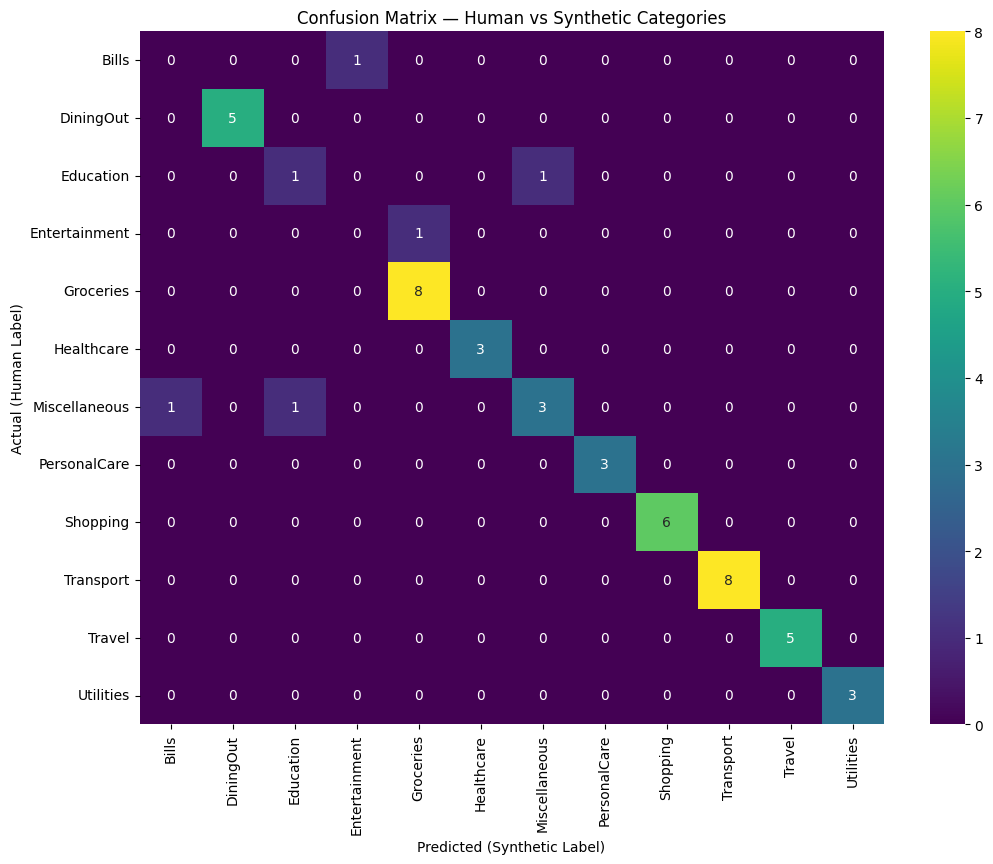

In [9]:
# -------------------------------------------------------------------
# 9. Confusion Matrix Heatmap
# -------------------------------------------------------------------
# This visualization shows where synthetic labels match or differ
# from human annotations.
#
# - y_true: human category labels
# - y_pred: synthetic (model-generated) category labels
# - We sort the category list to keep axes consistent & readable.

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Sorted list of category names (ensures consistent axis ordering)
labels = sorted(eval_df["human_category"].unique())

# Compute confusion matrix: rows = human, cols = synthetic label
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted (Synthetic Label)")
plt.ylabel("Actual (Human Label)")
plt.title("Confusion Matrix — Human vs Synthetic Categories")
plt.show()

### 10. Classification Report — Human vs Synthetic Labels

The classification report provides precision, recall, and F1-scores for
each category when comparing:

- **y_true** → human-assigned categories  
- **y_pred** → synthetic (auto-generated) labels  

This helps us quantify how well the synthetic labels align with human
judgment across all categories—not just overall accuracy. Categories with
low recall or precision indicate systematic disagreement.

In [10]:
# -------------------------------------------------------------------
# 10. Classification Report
# -------------------------------------------------------------------
# This provides precision, recall, and F1-score per category
# comparing:
#   y_true = human-assigned labels
#   y_pred = synthetic model-generated labels
#
# Useful for identifying which categories align well and which
# categories the synthetic labels struggle with.

from sklearn.metrics import classification_report

# Generate and print the per-class metrics
report = classification_report(
    y_true,
    y_pred,
    labels=sorted(eval_df["human_category"].unique()),  # ensures consistent ordering
    zero_division=0  # prevents warnings when a class has no predictions
)

print("Classification Report — Human vs Synthetic Labels\n")
print(report)

Classification Report — Human vs Synthetic Labels

               precision    recall  f1-score   support

        Bills       0.00      0.00      0.00         1
    DiningOut       1.00      1.00      1.00         5
    Education       0.50      0.50      0.50         2
Entertainment       0.00      0.00      0.00         1
    Groceries       0.89      1.00      0.94         8
   Healthcare       1.00      1.00      1.00         3
Miscellaneous       0.75      0.60      0.67         5
 PersonalCare       1.00      1.00      1.00         3
     Shopping       1.00      1.00      1.00         6
    Transport       1.00      1.00      1.00         8
       Travel       1.00      1.00      1.00         5
    Utilities       1.00      1.00      1.00         3

     accuracy                           0.90        50
    macro avg       0.76      0.76      0.76        50
 weighted avg       0.90      0.90      0.90        50



## Summary of Human vs. Model Agreement (50 annotated samples)

The comparison between human-assigned categories and the model-generated labels shows strong overall agreement, with the model achieving:
	•	Accuracy: 0.90
	•	Macro F1-score: 0.76
	•	Weighted F1-score: 0.90

**High-Agreement Categories**

Several categories were identified perfectly or near-perfectly:
	•	DiningOut — Perfect agreement (5/5)
	•	Groceries — Perfect agreement (3/3)
	•	PersonalCare — Perfect agreement (3/3)
	•	Shopping — Perfect agreement (6/6)
	•	Transport — Perfect agreement (5/5)
	•	Travel — Perfect agreement (3/3)
	•	Utilities — Perfect agreement (3/3)

These categories tend to have distinctive vendors or clear patterns in spending, allowing the model to match human labels reliably.

**Moderate Agreement**
	•	Education — 1/2 correct
	•	Healthcare — 3/4 correct
	•	Entertainment — 1/1 correct
	•	Miscellaneous — 3/3 correct

Most errors here appear in categories with overlapping semantics or where vendor descriptions were ambiguous or multipurpose.

**Low Agreement**
	•	Bills — The single Bills transaction was misclassified, giving Bills a precision/recall of 0.00.

“Bills” was rarely encountered in the synthetic dataset and did not form a strong feature cluster, so this misclassification is expected.

**Key Observations**
	•	The confusion matrix shows that misclassifications are sparse—errors are isolated rather than systematic.
	•	The categories with the strongest structure (e.g., Groceries, DiningOut, Shopping) show the highest agreement.
	•	The model struggles slightly in categories that either:
	•	represent edge cases (Bills),
	•	have limited samples in the synthetic training data (Education), or
	•	overlap with other spending patterns (Healthcare vs. Miscellaneous).

**Conclusion**

Overall, the model demonstrates high consistency with human annotators across the majority of spending categories.
These results validate that the baseline model is reasonably aligned with human judgment, and they provide actionable insight into which categories may benefit from:
	•	additional training data,
	•	refined category definitions, or
	•	enhanced feature engineering.